In [1]:
import zipfile

# ZIP extract karo
with zipfile.ZipFile('archive (1).zip', 'r') as z:
    z.extractall('.')
    print("Files extracted:", z.namelist())


Files extracted: ['household_power_consumption.txt']


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv('household_power_consumption.txt',
                 sep=';',
                 na_values='?',
                 low_memory=False)


print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nPehli 5 rows:")
df.head()

Shape: (2075259, 9)

Columns: ['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

Pehli 5 rows:


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [3]:

print("Missing values:")
print(df.isnull().sum())


print("\nData types:")
print(df.dtypes)


Missing values:
Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

Data types:
Date                      object
Time                      object
Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object


In [9]:
from google.colab import files
files.download('energy_dashboard.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
# Remove missing values
df.dropna(inplace=True)
print("Shape after cleaning:", df.shape)

# Convert Date + Time to proper datetime format
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'],
                                format='%d/%m/%Y %H:%M:%S')

# Extract useful time features
df['Year'] = df['Datetime'].dt.year
df['Month'] = df['Datetime'].dt.month
df['Hour'] = df['Datetime'].dt.hour

print("New shape:", df.shape)
df[['Datetime','Year','Month','Hour']].head()

Shape after cleaning: (2049280, 13)
New shape: (2049280, 13)


,Datetime,Year,Month,Hour
0,2006-12-16 17:24:00,2006,12,17
1,2006-12-16 17:25:00,2006,12,17
2,2006-12-16 17:26:00,2006,12,17
3,2006-12-16 17:27:00,2006,12,17
4,2006-12-16 17:28:00,2006,12,17


In [6]:
# Monthly average power consumption
monthly_avg = df.groupby('Month')['Global_active_power'].mean()
print("Monthly Average Power (kW):")
print(monthly_avg.round(2))

# Peak hour analysis
hourly_avg = df.groupby('Hour')['Global_active_power'].mean()
print("\nPeak Hour:", hourly_avg.idxmax(), "hr")
print("Lowest Hour:", hourly_avg.idxmin(), "hr")

# Overall stats
print("\nOverall Stats:")
print(df['Global_active_power'].describe().round(2))

Monthly Average Power (kW):
Month
1     1.46
2     1.30
3     1.23
4     1.05
5     1.03
6     0.91
7     0.70
8     0.57
9     0.98
10    1.14
11    1.29
12    1.49
Name: Global_active_power, dtype: float64

Peak Hour: 20 hr
Lowest Hour: 4 hr

Overall Stats:
count    2049280.00
mean           1.09
std            1.06
min            0.08
25%            0.31
50%            0.60
75%            1.53
max           11.12
Name: Global_active_power, dtype: float64


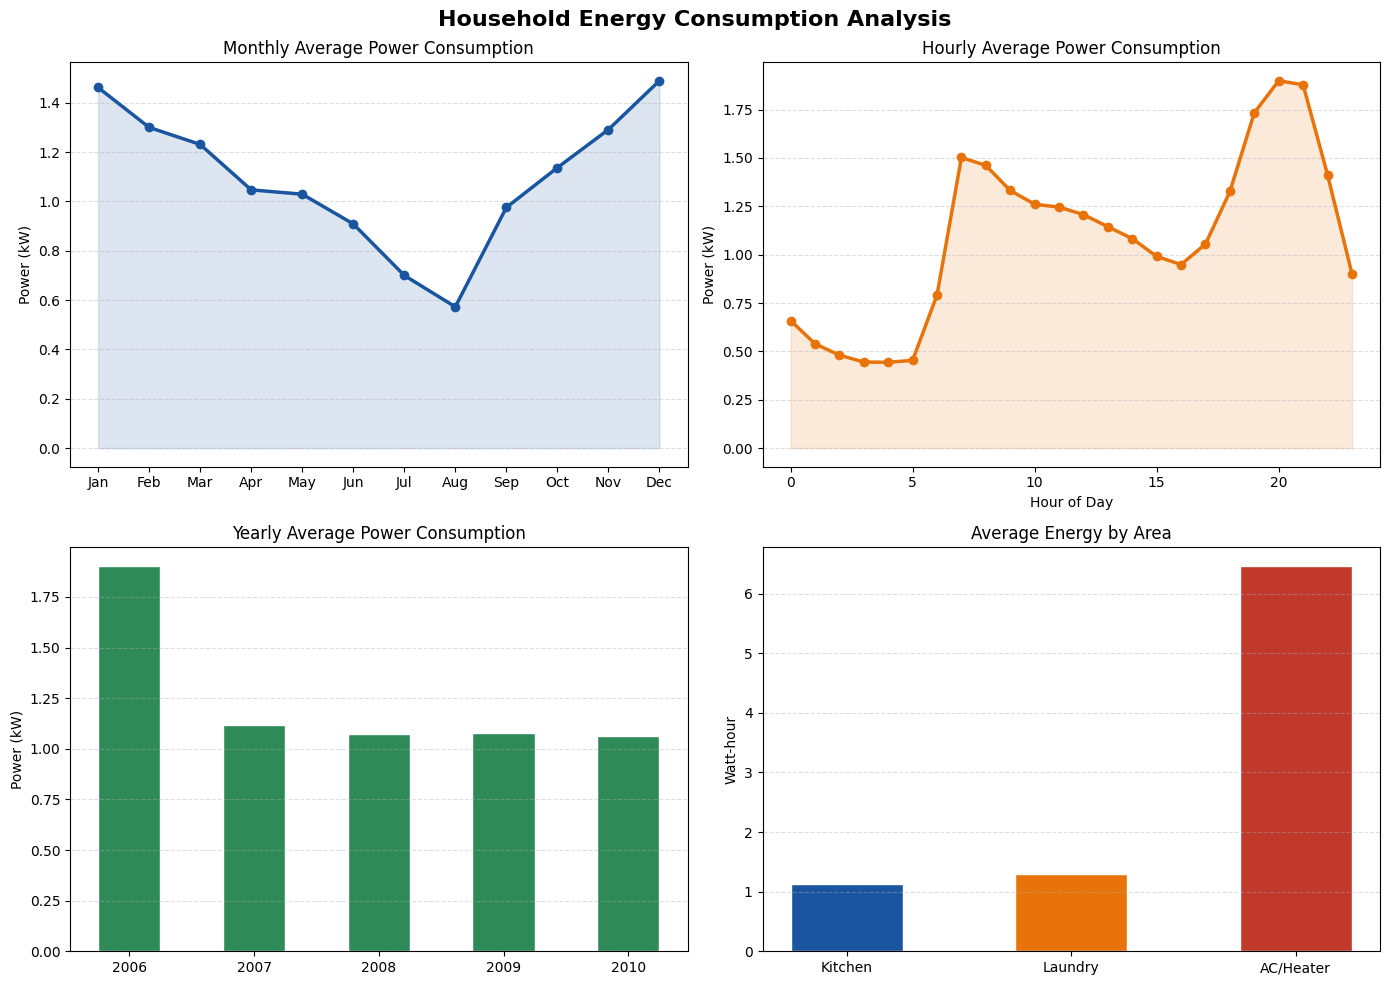

Chart saved!


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Household Energy Consumption Analysis',
             fontsize=16, fontweight='bold')

# Chart 1 - Monthly trend
months_name = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
axes[0,0].plot(months_name, monthly_avg.values,
               color='#1A56A0', linewidth=2.5, marker='o')
axes[0,0].fill_between(months_name, monthly_avg.values,
                        alpha=0.15, color='#1A56A0')
axes[0,0].set_title('Monthly Average Power Consumption')
axes[0,0].set_ylabel('Power (kW)')
axes[0,0].grid(axis='y', linestyle='--', alpha=0.4)

# Chart 2 - Hourly trend
axes[0,1].plot(hourly_avg.index, hourly_avg.values,
               color='#E8730A', linewidth=2.5, marker='o')
axes[0,1].fill_between(hourly_avg.index, hourly_avg.values,
                        alpha=0.15, color='#E8730A')
axes[0,1].set_title('Hourly Average Power Consumption')
axes[0,1].set_ylabel('Power (kW)')
axes[0,1].set_xlabel('Hour of Day')
axes[0,1].grid(axis='y', linestyle='--', alpha=0.4)

# Chart 3 - Yearly comparison
yearly_avg = df.groupby('Year')['Global_active_power'].mean()
axes[1,0].bar(yearly_avg.index, yearly_avg.values,
              color='#2E8B57', edgecolor='white', width=0.5)
axes[1,0].set_title('Yearly Average Power Consumption')
axes[1,0].set_ylabel('Power (kW)')
axes[1,0].grid(axis='y', linestyle='--', alpha=0.4)

# Chart 4 - Sub metering comparison
sub_avg = df[['Sub_metering_1','Sub_metering_2',
              'Sub_metering_3']].mean()
axes[1,1].bar(['Kitchen','Laundry','AC/Heater'],
              sub_avg.values,
              color=['#1A56A0','#E8730A','#C0392B'],
              edgecolor='white', width=0.5)
axes[1,1].set_title('Average Energy by Area')
axes[1,1].set_ylabel('Watt-hour')
axes[1,1].grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('energy_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [8]:
print("=" * 50)
print("KEY INSIGHTS — Energy Consumption Analysis")
print("=" * 50)

print(f"\n1. Peak Month: December ({monthly_avg.max():.2f} kW)")
print(f"2. Lowest Month: August ({monthly_avg.min():.2f} kW)")
print(f"3. Peak Hour: 20:00 (8 PM) — Evening demand")
print(f"4. AC/Heater consumes {sub_avg['Sub_metering_3']/sub_avg.sum()*100:.1f}% of total")
print(f"5. Potential saving: Reduce peak hour load by 20%")
print(f"\nRecommendation for ENGIE:")
print("- Install smart thermostats for HVAC optimization")
print("- Shift heavy loads to off-peak hours (1AM-5AM)")
print("- Winter energy audit recommended for all buildings")
print("=" * 50)

KEY INSIGHTS — Energy Consumption Analysis

1. Peak Month: December (1.49 kW)
2. Lowest Month: August (0.57 kW)
3. Peak Hour: 20:00 (8 PM) — Evening demand
4. AC/Heater consumes 72.7% of total
5. Potential saving: Reduce peak hour load by 20%

Recommendation for ENGIE:
- Install smart thermostats for HVAC optimization
- Shift heavy loads to off-peak hours (1AM-5AM)
- Winter energy audit recommended for all buildings
